In [ ]:
# pip install numpy pandas lasio matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import lasio as ls
import pandas as pd
# import openpyxl
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms
import random

В результате проведения спектрометрического гамма-каротажа (СГК) по стволу скважины получают массовые концентрации естественных радиоактивных элементов. Концентрации каждого элемента зависит от содержаний отдельных составляющих (минералов и неминеральных компонент) в горной породе и концентраций данного элемента в каждой из составляющих горной породы. Связь между концентрациями радиоактивных элементов и содержаниями компонент для большинства пластов можно записать в следующем виде: 
$$
C_{K} = M_{1} * A_{K 1} + M_{2} * A_{K 2}+ ...
$$

$$
C_{Th} = M_{1} * A_{Th 1} + M_{2} * A_{Th 2}+ ...
$$

$$
C_{U} = M_{1} * A_{U 1} + M_{2} * A_{U 2}+ ...
$$

$$
... = ...
$$
где <br>
С - Измеренные СГК концентрации ЕРО, <br>
M - массовые доли некоторых компонент породы, <br>
A - содержания ЕРО в каждом компоненте

В итоге получаем систему линейных уравнений которая в матричном виде выглядит так:
$$
{C}^{1 \times m} = {M}^{1 \times n} \times {A}^{n \times m}  
$$
где m - количество разных параметров которые мы можем измерять в скважине, n - количество компонент породы,  <br>
но отличить мы сможем только n = m составляющих горной породы, имеющих самые значимые радиоактивности.

In [ ]:
lasdata = ls.read('inp.las')
data = lasdata.stack_curves(['DEPT','LITO', 'POTA', 'THOR', 'RHOB','TRNP'], sort_curves=False) #Выбираем нужные нам параметры
data = np.c_[data, np.ones(data.shape[0])] #Добавляем столбец с единицами чтоб выполнялось последнее уравнение баланса
data[data[:,1]!=1,1] = 2 #Меняем в LITO все 3 и 4 на 2 (предполагаю что это тоже относится к глинам)
# lito = lasdata.get_curve('LITO').data # получаем столбец  с литологией чтоб отличать коллекторы от покрышек



In [6]:
is_coll = data[:,1] == 1
is_glin = data[:,1] == 2

#Разделяем и оставляем только нужные свойства в коллекторах и глинах
coll_prop = data[is_coll][:,2:]
glin_prop = data[is_glin][:,2:]

In [544]:
A_col = np.loadtxt('matrix_coll.out')
A_glin = np.loadtxt('matrix_glina.out')

In [170]:
A_min_glin = np.loadtxt('a_min_glin.in')
# invA_min_glin = np.linalg.inv(A_min_glin)

A_min_col = np.loadtxt('a_min_coll.in')
# invA_min_col = np.linalg.inv(A_min_col)

A_max_glin = np.loadtxt('a_max_glin.in')
# invA_max_glin = np.linalg.inv(A_max_glin)

A_max_col = np.loadtxt('a_max_coll.in')
# invA_max_col = np.linalg.inv(A_max_col)

In [522]:
A_max_glin_list = A_max_glin.flatten().tolist()
A_min_glin_list = A_min_glin.flatten().tolist()

A_min_col_list = A_min_col.flatten().tolist()
A_max_col_list = A_max_col.flatten().tolist()

In [14]:
def calc_mkm_model(A_coll: np.ndarray, A_glin: np.ndarray) -> np.ndarray:
    invM_coll = np.linalg.inv(A_coll)
    invM_glin = np.linalg.inv(A_glin)

    mkm_coll = coll_prop @ invM_coll
    mkm_glin = glin_prop @ invM_glin

    mkm = np.zeros_like(data)
    mkm[is_coll,:] = np.hstack((data[is_coll,:2],mkm_coll))
    mkm[is_glin,:] = np.hstack((data[is_glin,:2],mkm_glin))
    return mkm

Я отделял участки глин и участки коллекторов и по отдельности генетическим алгоритмом подбирал для них матрицы, в качестве fitness функции (т.е. функции по которой отбираются наилучшие особи) я использовал комбинированные значения из двух функций. Рассчитывается мкм модель и смотрим на ее показатели. Для глин это Доля отрицательных значений с весом 0.7 и Доля тех участков для суммарная доля глин меньше 30% с весом 0.3. Для коллекторов это Доля отрицательных значений с весом 0.7 и Доля тех участков для суммарная доля глин больше 30% с весом 0.3.

In [501]:
def calc_fitness_glin(A_glin: list):
    A_glin = np.array(A_glin).reshape(5,5)
    
    invM_glin = np.linalg.inv(A_glin)

    mkm_glin = glin_prop @ invM_glin

    fitness1 = np.sum(mkm_glin < 0) / mkm_glin.size #Доля отрицательных значений

    fitness2 = (mkm_glin[:,0] + mkm_glin[:,1] < 0.3).sum() / len(mkm_glin) #Доля тех участков для суммарная доля глин меньше 30%

    return fitness1*0.7 + fitness2*0.3,



def calc_fitness_coll(A_coll: list):
    A_coll = np.array(A_coll).reshape(5,5)

    invM_coll = np.linalg.inv(A_coll)

    mkm_coll = coll_prop @ invM_coll

    fitness1 = np.sum(mkm_coll < 0) / mkm_coll.size #Доля отрицательных значений

    fitness2 = (mkm_coll[:,0] + mkm_coll[:,1] > 0.3).sum() / len(mkm_coll) #Доля тех участков для суммарная доля глин больше 30%

    return fitness1*0.7 + fitness2*0.3,

Дальше непосредственно сам генетический алгоритм: 
Создаем начальную популяцию из рандомных значений в рамках заданных нами пределах для каждого значения матрицы. Каждая особь это матрица 5 на 5.
Скрещиваем особи, функцию для скрещивания выбрал двухточечный кроссинговер (мы представляем наши матрицы как один длинный вектор, в двух местах выбираем разрез и обмениваем отрезанные места между родителями) таким образом происходит обмен генами.
Далее с определенной вероятностью происходит мутация. В данном случае просто меняется одно из значений которое может меняться на рандомное в рамках диапазона.
Далее среди новой популяции происходит турнирный отбор, в данном случае все особи разбиваются по тройкам и среди них выбирается самая сильная с точки зрения фитнес функции.
И так множество генераций, в данном случае 400, но там уже после где то 200 и так ничего не меняется почти.


Поиск лучшей матрицы для глин

In [ ]:


creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Функция для создания случайной особи
def generate_random_individual():
    return [random.uniform(min_val, max_val) for min_val, max_val in zip(A_min_glin_list, A_max_glin_list)]

# Регистрируем создание особи
toolbox.register("individual", tools.initIterate, creator.Individual, generate_random_individual)

# Регистрируем создание популяции
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Регистрируем fitness функцию 
toolbox.register("evaluate", calc_fitness_glin)

# Скрещивание (two-point crossover)
def cxTwoPointCopy(ind1, ind2):
    """Двухточечный кроссовер"""
    size = len(ind1)
    point1 = random.randint(1, size)
    point2 = random.randint(1, size - 1)
    if point2 >= point1:
        point2 += 1
    else:  # swap points
        point1, point2 = point2, point1
    ind1[point1:point2], ind2[point1:point2] = ind2[point1:point2], ind1[point1:point2]
    return ind1, ind2

toolbox.register("mate", cxTwoPointCopy)

# Мутация (мутация гена на случайное значение в пределах границ)
def mutUniformInt(individual, indpb):
    
    for i in range(len(individual)):
        if random.random() < indpb:
            individual[i] = random.uniform(A_min_glin_list[i], A_max_glin_list[i])
    return individual,

toolbox.register("mutate", mutUniformInt, indpb=0.1)

# Турнирный отбор
toolbox.register("select", tools.selTournament, tournsize=3)

# Настройки генетического алгоритма
POPULATION_SIZE = 1000
NGEN = 400
CXPB = 0.5  # Вероятность скрещивания
MUTPB = 0.2  # Вероятность мутации

# Сбор статистики
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

# Logbook для записи прогресса
logbook = tools.Logbook()
logbook.header = ["gen", "eval"] + stats.fields



In [ ]:
# Запуск генетического алгоритма с помощью встроенной функции
final_population, logbook = algorithms.eaSimple(
    population=toolbox.population(n=POPULATION_SIZE),
    toolbox=toolbox,
    cxpb=CXPB,
    mutpb=MUTPB,
    ngen=NGEN,
    stats=stats,
    halloffame=tools.HallOfFame(1),
    verbose=True
)

# Печать лучшей особи
best_ind = tools.selBest(final_population, 1)[0]
print("Лучший индивидуум:", best_ind)
print("Приспособленность:", best_ind.fitness.values)

gen	nevals	avg     	std    	min     	max     
0  	1000  	0.334456	0.12347	0.110154	0.579642
1  	593   	0.252147	0.0871044	0.0970906	0.578297
2  	629   	0.214032	0.0826093	0.0873648	0.575841
3  	596   	0.185145	0.0726997	0.0873648	0.581049
4  	589   	0.179923	0.0831723	0.0824561	0.581908
5  	610   	0.161728	0.0719041	0.0749415	0.575186
6  	610   	0.136822	0.0537895	0.0728728	0.575106
7  	591   	0.114693	0.036986 	0.0685782	0.467142
8  	578   	0.101669	0.0305545	0.0685782	0.428202
9  	605   	0.0943217	0.0365702	0.0663231	0.48083 
10 	590   	0.0863569	0.0298932	0.0663231	0.432032
11 	569   	0.0819576	0.0267761	0.062595 	0.428512
12 	574   	0.0811879	0.0361449	0.0624635	0.569781
13 	600   	0.0764291	0.0271116	0.0624635	0.312237
14 	633   	0.0764316	0.0408794	0.0624635	0.570497
15 	613   	0.0724355	0.0321689	0.0618165	0.536126
16 	577   	0.0719896	0.0326132	0.0618165	0.438315
17 	606   	0.0726875	0.0364656	0.0617982	0.42754 
18 	620   	0.0701707	0.0340279	0.0606469	0.551075
19 	639   	0.069

In [504]:
def calc_metrics_glin(A_glin: list):

    A_glin = np.array(A_glin).reshape(5,5)
    
    invM_glin = np.linalg.inv(A_glin)

    mkm_glin = glin_prop @ invM_glin

    fitness1 = np.sum(mkm_glin < 0) / mkm_glin.size #Доля отрицательных значений

    fitness2 = (mkm_glin[:,0] + mkm_glin[:,1] < 0.3).sum() / len(mkm_glin) #Доля тех участков для суммарная доля глин меньше 30%

    return fitness1, fitness2

Видим показатели лучшей особи, т.е 5% отрицательных значений и 6% строк где сумма глин меньше 30%

In [520]:
calc_metrics_glin(best_ind)

(np.float64(0.05358187134502924), np.float64(0.062317251461988306))

In [521]:
best_ind_glin = best_ind

Далее делаем то же самое но с коллекторами и со своей функцией приспособленности.

Поиск лучшей матрицы для коллекторов

In [ ]:


creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Функция для создания случайной особи
def generate_random_individual():
    return [random.uniform(min_val, max_val) for min_val, max_val in zip(A_min_col_list, A_max_col_list)]

# Регистрируем создание особи
toolbox.register("individual", tools.initIterate, creator.Individual, generate_random_individual)

# Регистрируем создание популяции
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Регистрируем функцию 
toolbox.register("evaluate", calc_fitness_coll)

# Скрещивание (two-point crossover)
def cxTwoPointCopy(ind1, ind2):
    """Двухточечный кроссовер"""
    size = len(ind1)
    point1 = random.randint(1, size)
    point2 = random.randint(1, size - 1)
    if point2 >= point1:
        point2 += 1
    else:  # swap points
        point1, point2 = point2, point1
    ind1[point1:point2], ind2[point1:point2] = ind2[point1:point2], ind1[point1:point2]
    return ind1, ind2

toolbox.register("mate", cxTwoPointCopy)

# Мутация (мутация гена на случайное значение в пределах границ)
def mutUniformInt(individual, indpb):
    """Мутация с изменением гена на случайное значение в пределах границ"""
    for i in range(len(individual)):
        if random.random() < indpb:
            individual[i] = random.uniform(A_min_glin_list[i], A_max_glin_list[i])
    return individual,

toolbox.register("mutate", mutUniformInt, indpb=0.1)

# Турнирный отбор
toolbox.register("select", tools.selTournament, tournsize=3)

# Настройки генетического алгоритма
POPULATION_SIZE = 1000
NGEN = 400
CXPB = 0.5  # Вероятность кроссинговера
MUTPB = 0.2  # Вероятность мутации

# Сбор статистики
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

# Logbook для записи прогресса
logbook = tools.Logbook()
logbook.header = ["gen", "eval"] + stats.fields



d:\Python\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
d:\Python\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [ ]:

final_population, logbook = algorithms.eaSimple(
    population=toolbox.population(n=POPULATION_SIZE),
    toolbox=toolbox,
    cxpb=CXPB,
    mutpb=MUTPB,
    ngen=NGEN,
    stats=stats,
    halloffame=tools.HallOfFame(1),
    verbose=True
)


best_ind = tools.selBest(final_population, 1)[0]
print("Лучший индивидуум:", best_ind)
print("Приспособленность:", best_ind.fitness.values)

gen	nevals	avg     	std     	min      	max     
0  	1000  	0.223553	0.132235	0.0119102	0.717897
1  	592   	0.131183	0.0901939	0.0119102	0.702529
2  	588   	0.0807717	0.0677808	0.0105081	0.58    
3  	584   	0.053719 	0.0674717	0.00853879	0.572052
4  	584   	0.0394159	0.0730401	0.00853879	0.606184
5  	589   	0.033519 	0.0751198	0.00853879	0.632336
6  	573   	0.0260436	0.063892 	0.00853879	0.66382 
7  	615   	0.0236474	0.0646746	0.00827885	0.576314
8  	607   	0.0208918	0.0594627	0.00827097	0.583679
9  	594   	0.0222142	0.068533 	0.00816857	0.536046
10 	602   	0.0209143	0.0646174	0.00790075	0.521197
11 	602   	0.0211714	0.0683488	0.00790075	0.538362
12 	591   	0.0186011	0.0584417	0.00790075	0.529019
13 	589   	0.0201199	0.0618439	0.00790075	0.521489
14 	610   	0.0220317	0.0713309	0.00790075	0.645758
15 	615   	0.0217922	0.0687373	0.00790075	0.519653
16 	599   	0.0216558	0.0725436	0.00788499	0.571603
17 	600   	0.023976 	0.078316 	0.00788499	0.633879
18 	625   	0.0220537	0.0689148	0.0078849

In [528]:
def calc_metrics_coll(A_coll: list):
    A_coll = np.array(A_coll).reshape(5,5)

    invM_coll = np.linalg.inv(A_coll)

    mkm_coll = coll_prop @ invM_coll

    fitness1 = np.sum(mkm_coll < 0) / mkm_coll.size #Доля отрицательных значений

    fitness2 = (mkm_coll[:,0] + mkm_coll[:,1] > 0.3).sum() / len(mkm_coll) #Доля тех участков для суммарная доля глин больше 30%

    return fitness1,fitness2

Видим лучшую особь по коллекторам: 0.5% отрицательных значений и 1% строк где сумма глин больше 30%

In [529]:
calc_metrics_coll(best_ind)

(np.float64(0.005986608901142182), np.float64(0.011815675462780622))

In [530]:
best_ind_coll = best_ind

In [532]:
best_mkm_model = calc_mkm_model(np.array(best_ind_coll).reshape(5,5),np.array(best_ind_glin).reshape(5,5))

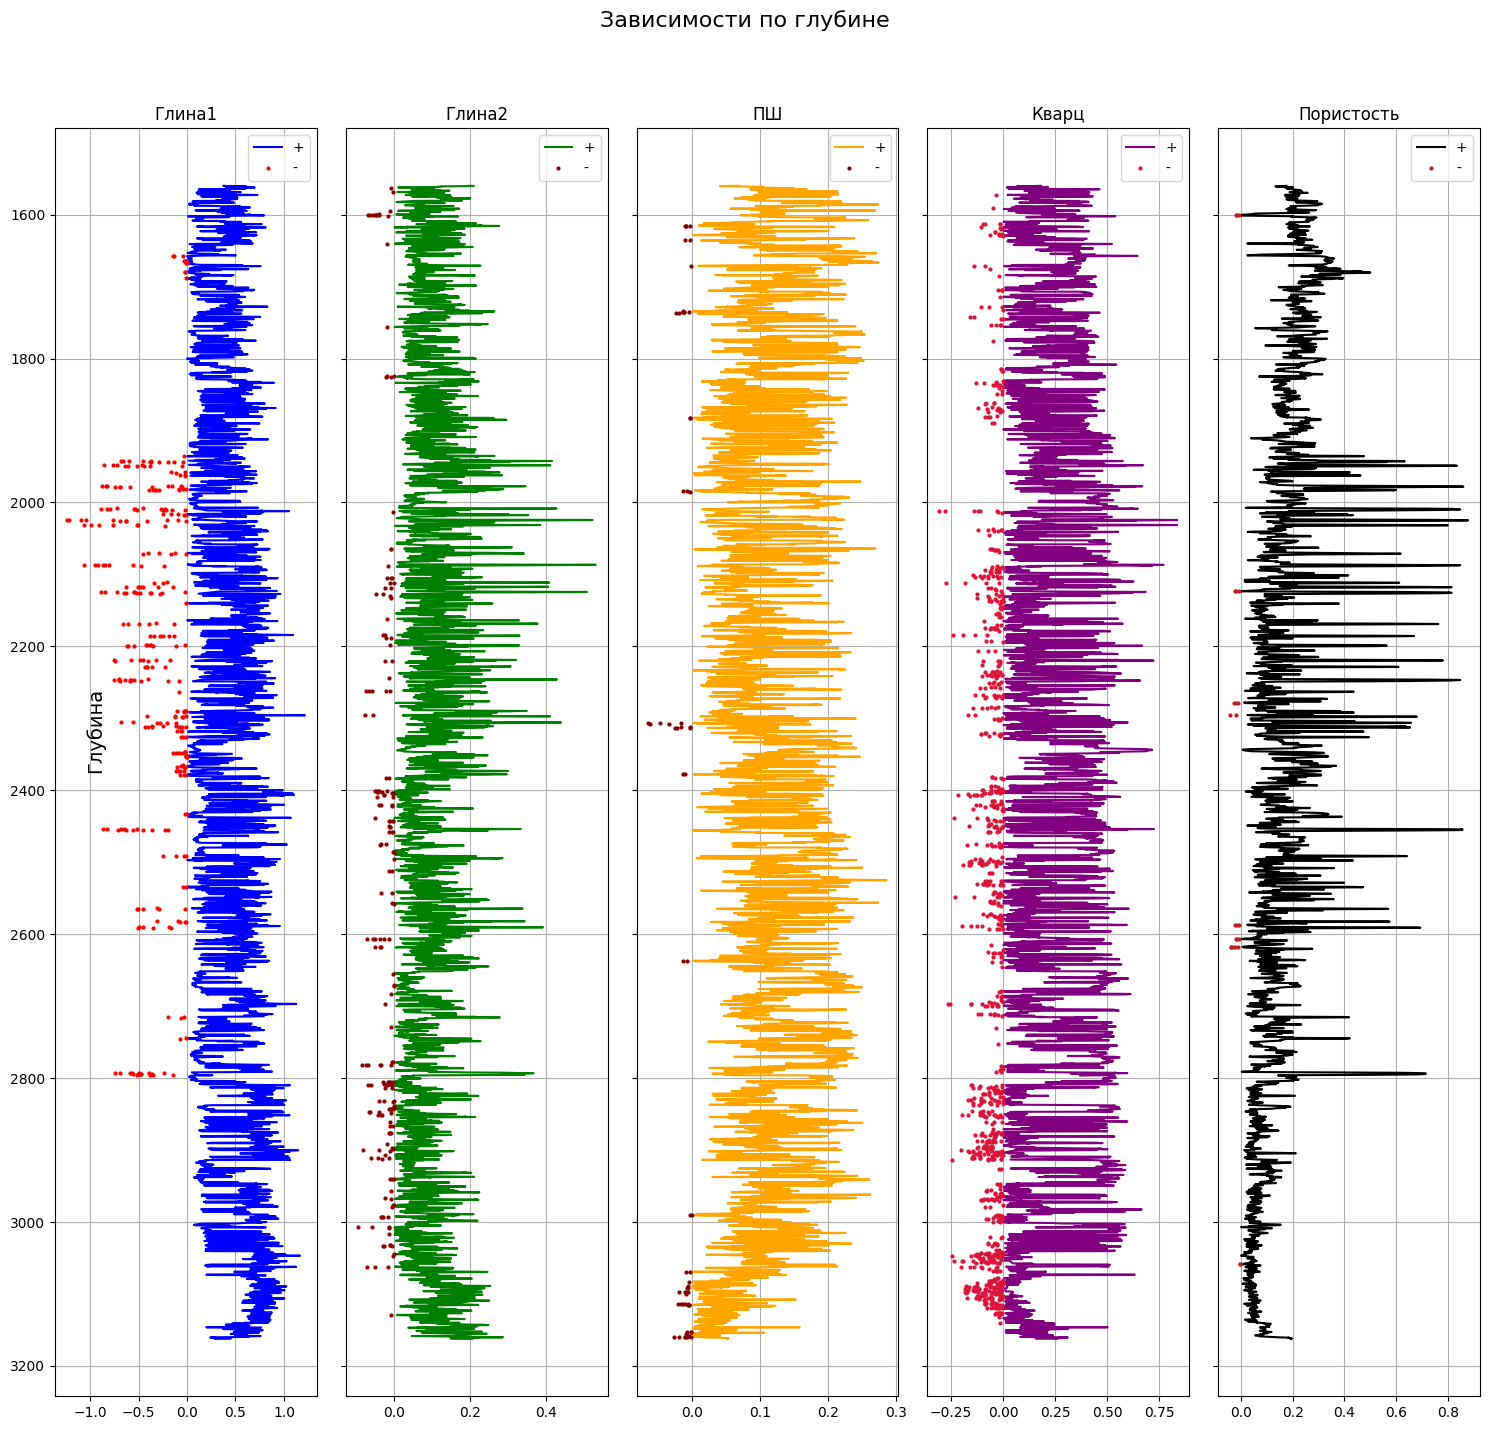

In [ ]:


depth = best_mkm_model[:, 0]

fig, axes = plt.subplots(ncols=5, figsize=(15, 15), sharex=False, sharey=True)

for ax in axes:
    ax.invert_yaxis()

def plot_with_sign(ax, x, y, positive_color, negative_color):
    pos_mask = x >= 0
    neg_mask = ~pos_mask
    ax.plot(x[pos_mask], y[pos_mask], color=positive_color, label='+')
    ax.plot(x[neg_mask], y[neg_mask], color=negative_color, label='-', marker='o', markersize=2, ls='')


plot_with_sign(axes[0], best_mkm_model[:, 2], depth, 'blue', 'red')
axes[0].set_title('Глина1')


plot_with_sign(axes[1], best_mkm_model[:, 3], depth, 'green', 'darkred')
axes[1].set_title('Глина2')


plot_with_sign(axes[2], best_mkm_model[:, 4], depth, 'orange', 'maroon')
axes[2].set_title('ПШ')


plot_with_sign(axes[3], best_mkm_model[:, 5], depth, 'purple', 'crimson')
axes[3].set_title('Кварц')


plot_with_sign(axes[4], best_mkm_model[:, 6], depth, 'black', 'firebrick')
axes[4].set_title('Пористость')


for ax in axes:
    ax.legend()


fig.text(0.06, 0.5, 'Глубина', va='center', rotation='vertical', fontsize=14)


for ax in axes:
    ax.grid(True)

plt.suptitle('Зависимости по глубине', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

In [ ]:

columns_to_check = best_mkm_model[:, 2:]

flat_columns = columns_to_check.flatten()

num_negatives = np.sum(flat_columns < 0)

total_elements = flat_columns.size

fraction_negative = num_negatives / total_elements

print(f"Доля отрицательных значений среди столбцов 3-7: {fraction_negative:.2%}")

Доля отрицательных значений среди столбцов 3-7: 3.85%


In [546]:
mkm_model_lab = calc_mkm_model(A_col,A_glin)

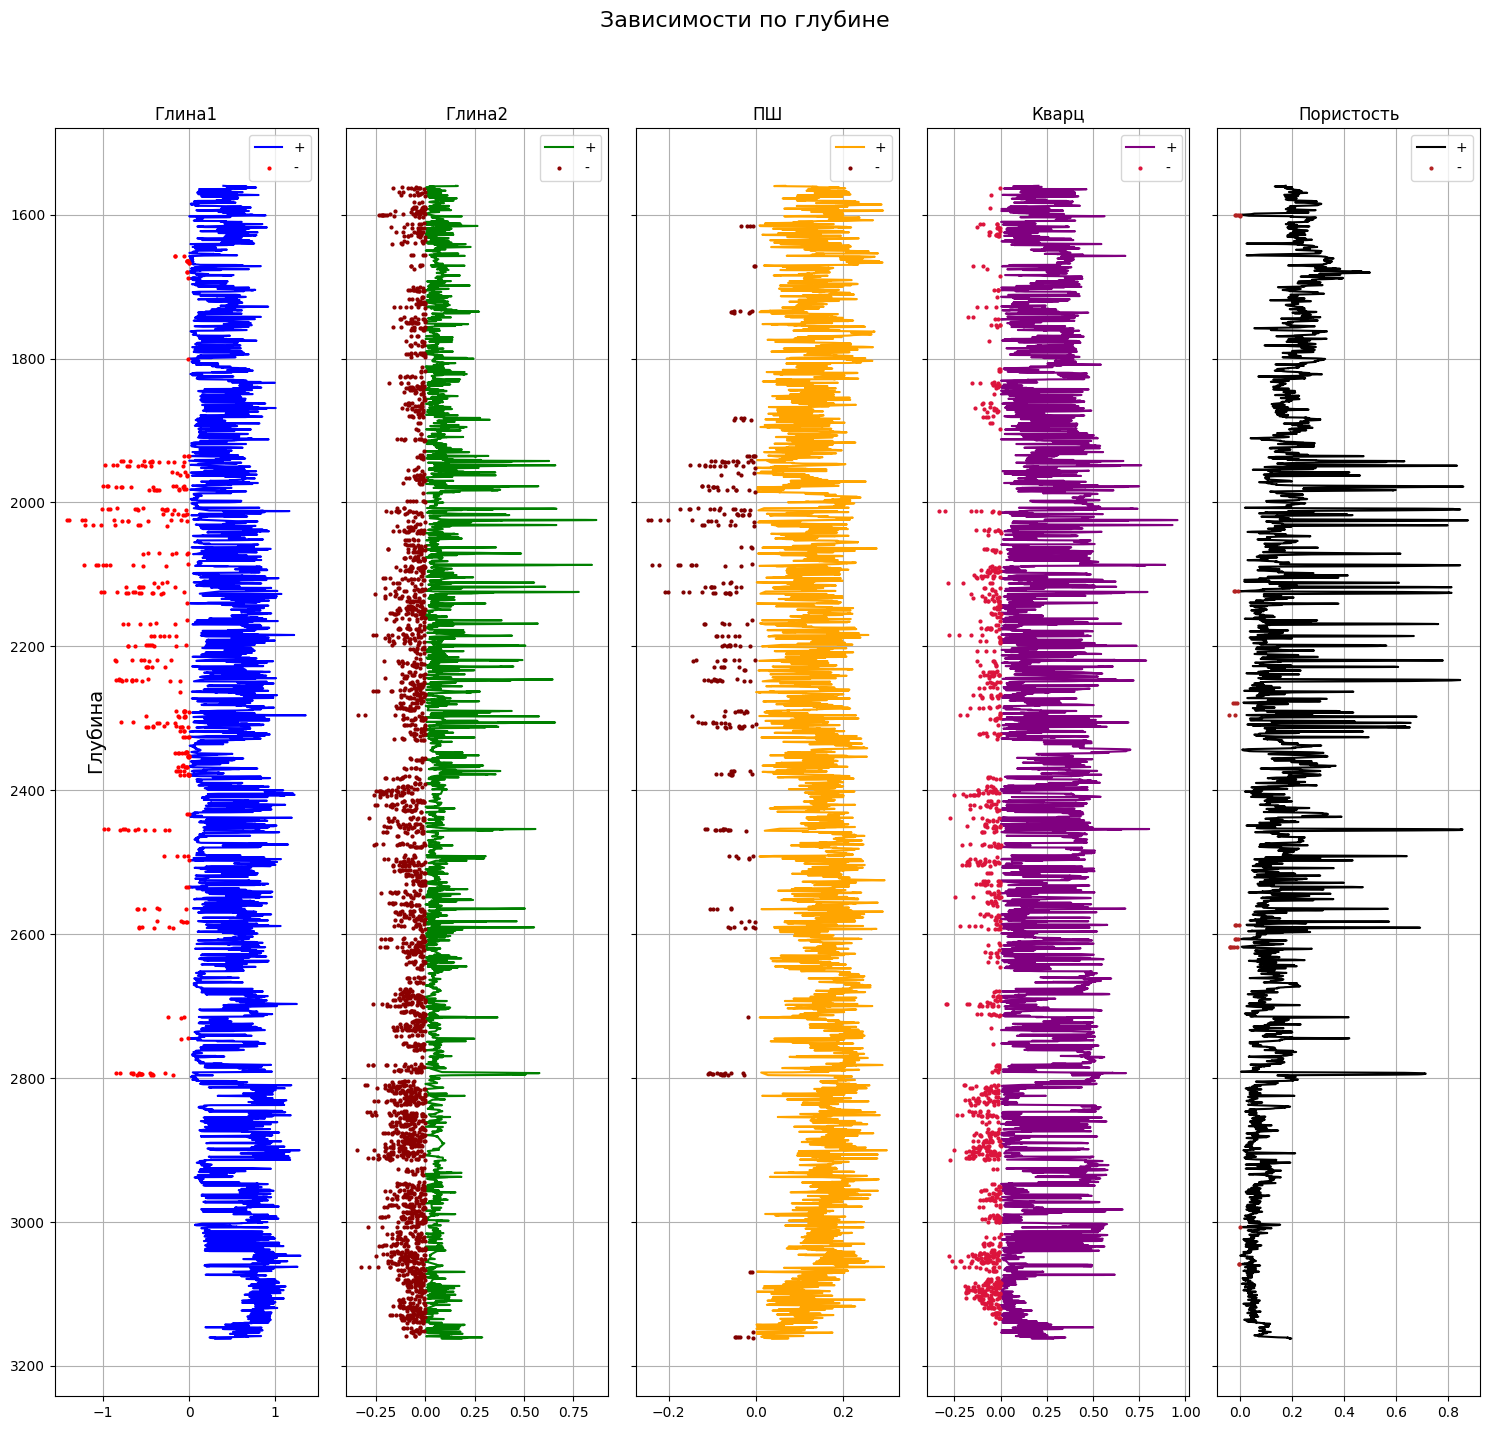

In [ ]:



depth = mkm_model_lab[:, 0]

fig, axes = plt.subplots(ncols=5, figsize=(15, 15), sharex=False, sharey=True)


for ax in axes:
    ax.invert_yaxis()


def plot_with_sign(ax, x, y, positive_color, negative_color):
    pos_mask = x >= 0
    neg_mask = ~pos_mask
    ax.plot(x[pos_mask], y[pos_mask], color=positive_color, label='+')
    ax.plot(x[neg_mask], y[neg_mask], color=negative_color, label='-', marker='o', markersize=2, ls='')

plot_with_sign(axes[0], mkm_model_lab[:, 2], depth, 'blue', 'red')
axes[0].set_title('Глина1')


plot_with_sign(axes[1], mkm_model_lab[:, 3], depth, 'green', 'darkred')
axes[1].set_title('Глина2')


plot_with_sign(axes[2], mkm_model_lab[:, 4], depth, 'orange', 'maroon')
axes[2].set_title('ПШ')


plot_with_sign(axes[3], mkm_model_lab[:, 5], depth, 'purple', 'crimson')
axes[3].set_title('Кварц')


plot_with_sign(axes[4], mkm_model_lab[:, 6], depth, 'black', 'firebrick')
axes[4].set_title('Пористость')


for ax in axes:
    ax.legend()


fig.text(0.06, 0.5, 'Глубина', va='center', rotation='vertical', fontsize=14)


for ax in axes:
    ax.grid(True)


plt.suptitle('Зависимости по глубине', fontsize=16)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.show()